# Homework 1 Part 2 - Solutions

---

In [1]:
# Import libraries and magics

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')
import pandas as pd

---

# Exercise 1 (15 points)

**Consider synthetic noisy quadratic data of the form**

$$t=x^2 + \epsilon$$

**where $\epsilon$ is zero-mean additive Gaussian noise.**

**You will build a linear regression model that uses Laplacian basis functions as features:**

\begin{align*}
\phi_j(x) = \exp\left\{-\frac{|x-\mu_j|)}{b}\right\}
\end{align*}

**with centers $\mu_\in\{-1.5,-0.5, 0.5, 1.5\}$ (for $j=1,2,3,4$), and a fixed scale parameter $b=0.3$.**

1. (8 points) **Generate a training set of $N_{\text{train}}=60$ samples by drawing $x$ uniformly from the interval $[−2,2]$ and adding Gaussian noise with standard deviation $0.4$. Fit a linear regression model using the Laplacian basis functions above. Include an intercept term. Complete the functions below while adhering to their format.**

In [2]:
def NoisyQuadraticData(N, a, b, sigma):
    '''Generates N data points in the range [a,b) sampled from a x^2 function
    with additive zero-mean Gaussian random noise with standard deviation sigma'''
    
    # N input samples, evenly spaced numbers between [a,b) incrementing by 1/N
    x = np.linspace(a,b,N)
    
    # draw N sampled from a univariate Gaussian distribution with mean 0, sigma standard deviation and N data points
    noise = np.random.normal(0,sigma,N)
    
    # desired values, noisy sinusoidal
    t = x**2 + noise
    
    return x, t

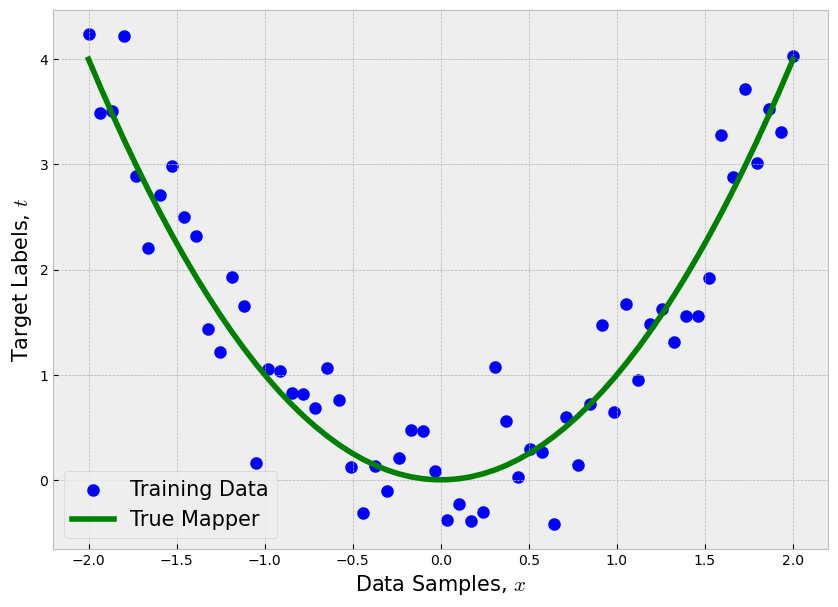

In [3]:
# Generate input samples and desired values
N_train = 60 # number of data samples for training

a, b = [-2,2] # data samples interval

sigma_train = 0.4 # standard deviation of the zero-mean Gaussian noise -- training data

x_train, t_train = NoisyQuadraticData(N_train, a, b, sigma_train)
x_true, t_true = NoisyQuadraticData(N_train, a, b, 0)

# Plotting
plt.figure(figsize=(10,7))
plt.scatter(x_train, t_train, c='b', linewidths=3, label = 'Training Data')
plt.plot(x_true, t_true, 'g', linewidth=4, label = 'True Mapper')
plt.legend(fontsize=15)
plt.xlabel('Data Samples, $x$',size=15)
plt.ylabel('Target Labels, $t$',size=15);

In [5]:
def LaplacianRegression(x,t,b=0.3):
    '''Fit a regression model with Laplacian features to the data input data x and desire values t'''
    
    # Compute feature matrix X with Gaussian basis functions features
    X = np.array([np.exp(-np.abs(x-mu)/b) for mu in [-1.5,-0.5, 0.5, 1.5]]).T 
    X = np.hstack((np.ones((X.shape[0],1)),X)) #adding dummy column of 1s to learn the bias term
    
    # Compute the solution for the parameters w
    w = np.linalg.inv(X.T@X)@X.T@t
    
    # Compute model prediction
    y = X@w
    
    return w, y

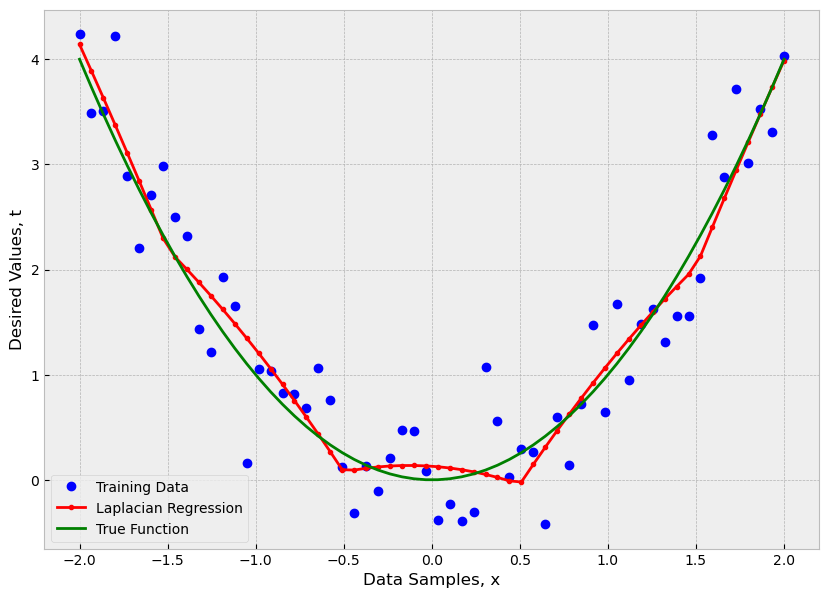

In [11]:
# Find the parameters that fit the noisy sinusoidal
w, y_train = LaplacianRegression(x_train,t_train,b=5) 

plt.figure(figsize=(10,7))
plt.plot(x_train,t_train,'bo', label='Training Data')
plt.plot(x_train,y_train,'.-r', label = 'Laplacian Regression')
plt.plot(x_true,t_true,'g', label = 'True Function')
plt.legend()
plt.xlabel('Data Samples, x')
plt.ylabel('Desired Values, t');

Note that I changed $b=5$, because it **visually** provides a better fitting. A good homework problem would have been to run cross-validation to find the best value for $b$.

2. (7 points) **Generate an independent test set of $N_{\text{test}}=30$ points from the same process with noise standard deviation $0.1$. Use your fitted model to predict on the test set and report the test mean-squared error.**

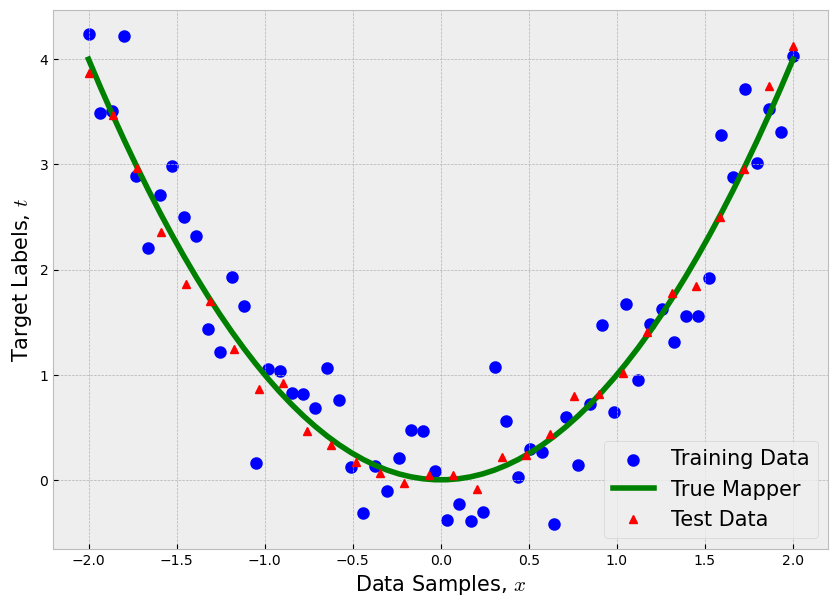

In [18]:
N_test = 30 # number of data samples for test
a, b = [-2,2] # data samples interval
sigma_test = 0.1 # standard deviation of the zero-mean Gaussian noise -- test data
x_test, t_test = NoisyQuadraticData(N_test, a, b, sigma_test) # Test Data

# Plotting
plt.figure(figsize=(10,7))
plt.scatter(x_train, t_train, c='b', linewidths=3, label = 'Training Data')
plt.plot(x_true, t_true, 'g', linewidth=4, label = 'True Mapper')
plt.plot(x_test, t_test, 'r^', label = 'Test Data')
plt.legend(fontsize=15)
plt.xlabel('Data Samples, $x$',size=15)
plt.ylabel('Target Labels, $t$',size=15);

In [19]:
def LaplacianRegression_test(x,w,b=0.3):
    
    # Feature matrix for test set
    X = np.array([np.exp(-np.abs(x-mu)/b) for mu in [-1.5,-0.5, 0.5, 1.5]]).T 
    X = np.hstack((np.ones((X.shape[0],1)),X))
    
    # Prediction for test set
    y = X@w
    
    return y

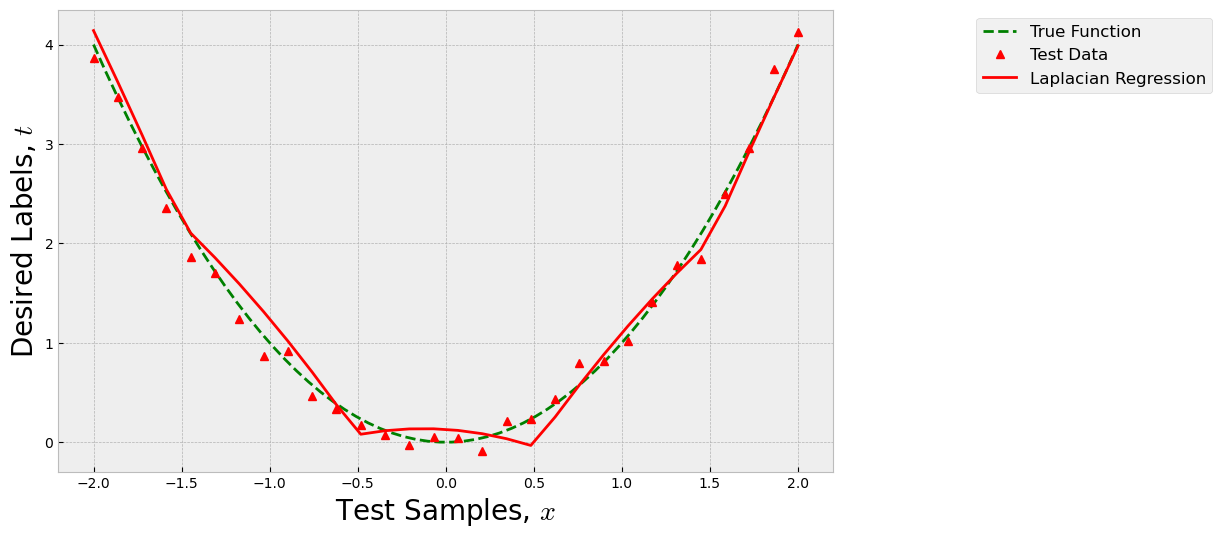

In [20]:
y_test = LaplacianRegression_test(x_test, w, b=5)

# Plotting
fig=plt.figure(figsize=(10,6))
plt.plot(x_true, t_true, '--g', label = 'True Function')
plt.plot(x_test, t_test, 'r^', label = 'Test Data')
plt.plot(x_test, y_test,'r', label = 'Laplacian Regression')
plt.legend(bbox_to_anchor=(1.5, 1),fontsize=12,ncol=1)
plt.xlabel('Test Samples, $x$', fontsize=20)
plt.ylabel('Desired Labels, $t$', fontsize=20);

---

# Exercise 2 (15 points)

**A city ride-share company wants to forecast the average number of trips per hour for the upcoming weekend. They model the hourly trip count as a Poisson random variable with unknown rate $\lambda$ ($\lambda>0$). The Poisson PMF is:** 

$$p(x|\lambda) = \frac{\lambda^x e^{-\lambda}}{x!}, \qquad x\in\{0,1,2,3,\dots\}$$

**The analytics team places a Gamma prior on $\lambda$ with parameters $\alpha=5$ and $\beta=0.5$. The Gamma density is:**

$$p(\lambda|\alpha,\beta)=\frac{\beta^{\alpha}}{\Gamma(\alpha)} \lambda^{\alpha-1} e^{-\beta\lambda}$$

**Answer the following questions:**

1. (7 points) **Derive the maximum-likelihood estimator (MLE) and the MAP estimator for $\lambda$. Show all steps in your derivation.**

#### MLE Estimate

The data likelihood is given by:

\begin{align*}
\mathcal{L}^0 = \prod_{i=1}^N \frac{\lambda^{x_i} e^{-\lambda}}{x_i!}
\end{align*}

We want to find $\lambda$ such that: $\lambda = \arg_{\lambda}\max \mathcal{L}^0$. We can take the log-likelihood to simplify derivatives. The log-likelihood is then given by:

\begin{align*}
\mathcal{L} &= \ln \mathcal{L}^0\\
&= \ln \prod_{i=1}^N \frac{\lambda^{x_i} e^{-\lambda}}{x_i!}\\
&= \sum_{i=1}^N \left(x_i \ln(\lambda) -\lambda - \ln(x_i!)\right)
\end{align*}

Now, we can take the derivative with respect to $\lambda$, set it equal to zero, and solve for $\lambda$.

\begin{align*}
\frac{\partial\mathcal{L}}{\partial\lambda} &= 0 \iff \frac{\sum_{i=1}^N x_i}{\lambda} -N = 0 \iff \lambda = \frac{\sum_{i=1}^N x_i}{N}
\end{align*}

The MLE estimate for $\lambda$, as expected, is the expected value of the log-likelihood: $\lambda_{\text{MLE}} =  \frac{\sum_{i=1}^N x_i}{N}$.

#### MAP Estimate

The posterior probability is proportional to the data likelihood times the prior probability:

\begin{align*}
\mathcal{L}^0 &= \left(\prod_{i=1}^N \frac{\lambda^{x_i} e^{-\lambda}}{x_i!}\right)\frac{\beta^{\alpha}}{\Gamma(\alpha)} \lambda^{\alpha-1} e^{-\beta\lambda}\\
&= \left(\prod_{i=1}^N \frac{1}{x_i!}\right) \lambda^{\sum_{i=1}^N x_i} e^{-N\lambda}\frac{\beta^{\alpha}}{\Gamma(\alpha)} \lambda^{\alpha-1} e^{-\beta\lambda}\\
\end{align*}

Since we are solving a similar optimization problem, i.e., $\lambda = \arg_{\lambda}\max \mathcal{L}^0$, we can discard constant terms:

\begin{align*}
\mathcal{L}^0 &= \left(\prod_{i=1}^N \frac{1}{x_i!}\right) \lambda^{\sum_{i=1}^N x_i} e^{-N\lambda}\frac{\beta^{\alpha}}{\Gamma(\alpha)} \lambda^{\alpha-1} e^{-\beta\lambda}\\
&\propto \lambda^{\sum_{i=1}^N x_i + \alpha-1} e^{-(\beta+N)\lambda}\\
\end{align*}

Taking the log-likelihood:

\begin{align*}
\mathcal{L} &= \ln \mathcal{L}^0\\
&= \left(\sum_{i=1}^N x_i + \alpha-1\right) \ln(\lambda) - (\beta+N)\lambda
\end{align*}

Now, we can take the derivative with respect to (wrt) $\lambda$, set it equal to zero, and solve for $\lambda$.

\begin{align*}
\frac{\partial\mathcal{L}}{\partial\lambda} &= 0 \iff \frac{\sum_{i=1}^N x_i + \alpha-1}{\lambda} - (\beta+N) = 0 \iff \lambda = \frac{\sum_{i=1}^N x_i + \alpha-1}{\beta+N}
\end{align*}

From the MAP observed likelihood, we see that the **posterior** and the **prior** probability have the same shape, hence they have a **<font color='blue'>conjugate prior</font>** relationship. The pseudo-code for updated the prior is as follows:

1. Iteration $t=0$
2. Initialize the parameters of the prior probability, $\alpha^{(t)}$ and $\beta^{(t)}$
3. As data comes in:
    1. Compute the posterior probability, $\mathcal{L}_{\text{MAP}}^{(t)} = P(\mathbf{x}|\mu)P(\mu|\alpha^{(t)},\beta^{(t)})$
    2. Make an estimate for the parameter, $\mu_{\text{MAP}}^{(t)}$
    3. Update parameters of prior probability:
    \begin{align*}
    \alpha^{(t+1)} &\leftarrow \alpha^{(t)} + \sum_{i=1}^N x_i\\
    \beta^{(t+1)} &\leftarrow \beta^{(t)} + N
    \end{align*}
    4. $t \leftarrow t + 1$

2. (8 points) **Suppose the dataset ```hourly_trips.npy``` is the dataset coming in hourly (one sample at a time) starting Feb 12 at 4pm.**
    * **Start with the prior $\alpha=3$ and $\beta=1$.**
    * **As each hourly observation arrives, update the prior parameters and record your estimates. Produce a plot that shows how the estimated $\lambda$ evolves with sample index $(t)$, showing both the MLE and the MAP.**
    * **For reference, the data-generating rate is $\lambda=10$.**

554.7830615642315 56


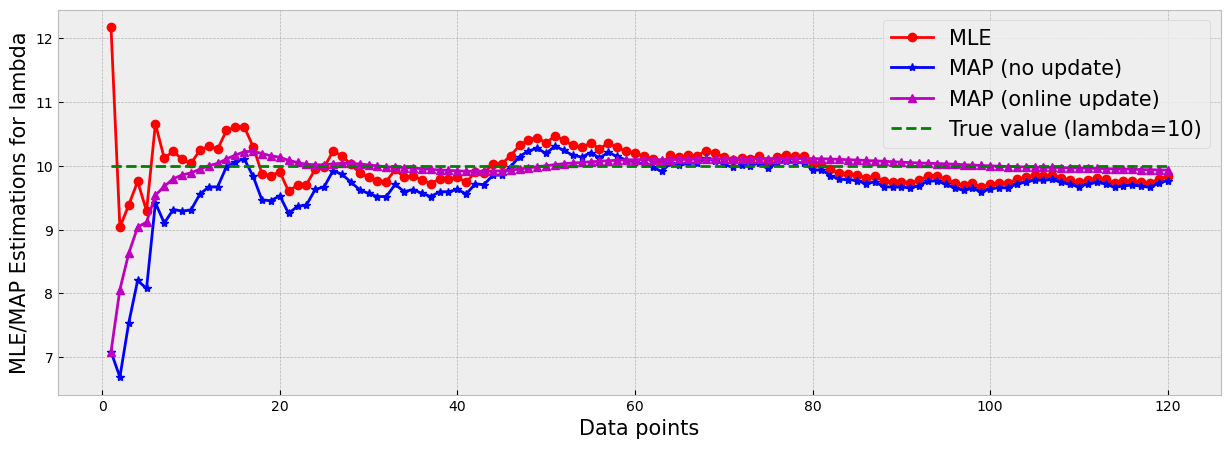

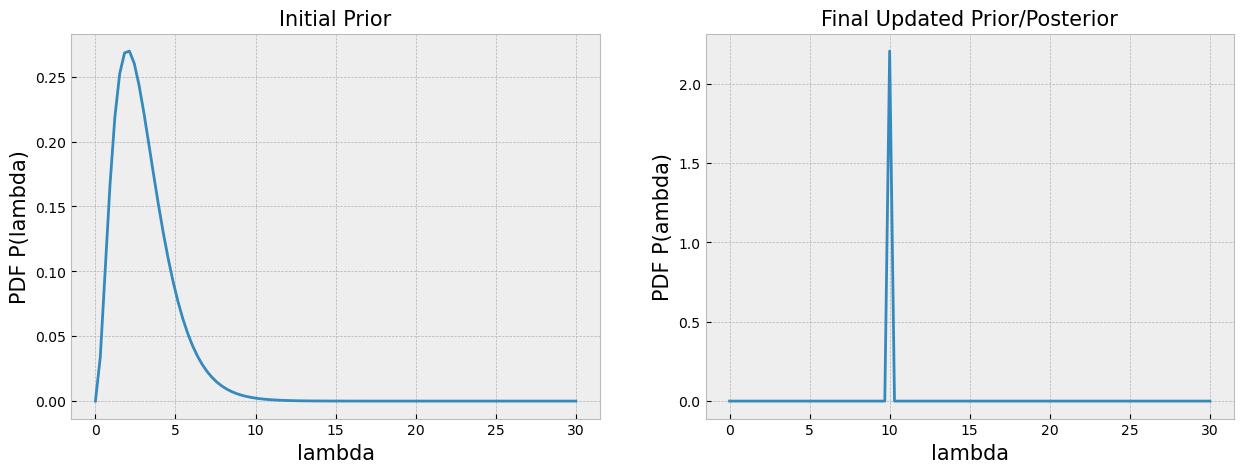

In [26]:
import scipy.stats as stats

# Loading data
data = np.load('hourly_trips.npy')
N = len(data)

# Prior Probability parameters
a = 3; a_init = a
b = 1;  b_init = b

# Computing MLE and MAP estimates as data is being collected
mu_MLE = []
mu_MAP = []
mu_MAP_update = []
for i in range(1,N+1):
    mu_MLE += [np.sum(data[:i])/len(data[:i])]
    mu_MAP += [(np.sum(data[:i])+a_init-1)/(len(data[:i])+b_init)]
    mu_MAP_update += [(np.sum(data[:i])+a-1)/(len(data[:i])+b)]
    a += np.sum(data[:i])
    b += len(data[:i])
    if i==10:
        print(a, b)

# Plotting estimates
plt.figure(figsize=(15,5))
plt.plot(range(1,N+1), mu_MLE, '-or', label='MLE')
plt.plot(range(1,N+1), mu_MAP, '-*b', label='MAP (no update)')
plt.plot(range(1,N+1), mu_MAP_update, '-^m', label='MAP (online update)')
plt.plot(range(1,N+1), [10]*N, '--g', label='True value (lambda=10)')
plt.xlabel('Data points',size=15)
plt.ylabel('MLE/MAP Estimations for lambda',size=15)
plt.legend(fontsize=15)
plt.show();

# Plotting Initial and Final Update Prior
x=np.linspace(0,30,100)
Gamma_initial = stats.gamma(a= a_init, scale=1/b_init)
Gamma_updated = stats.gamma(a=a, scale=1/b)

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(x, Gamma_initial.pdf(x)); plt.title('Initial Prior', size=15)
plt.xlabel('lambda',size=15); plt.ylabel('PDF P(lambda)',size=15)
plt.subplot(1,2,2)
plt.plot(x, Gamma_updated.pdf(x)); plt.title('Final Updated Prior/Posterior', size=15)
plt.xlabel('lambda',size=15); plt.ylabel('PDF P(ambda)',size=15);

As you can see from the first plot, the online update using the conjugate prior relationship has sped the convergence of the parameter estimation to the true value ($\lambda=10$).

In addition, from the last two plots, we see that the initial prior (on the left) the density at $\lambda=10$ (the true value) is almost 0. But the final update prior (figure on the right) is much sharper around the true value with less uncertainty.

---

# Exercise 3 (15 points)

**In this problem, you will be working with a crab dataset. The dataset contains 200 samples. Each sample is a 7-dimensional vector representing crab attributes (front lip width, rear width, length, width, depth, male and female), namely 5 morphological measurements on 50 crabs each of two color forms and both sexes, of the species *Leptograpsus* variegatus collected at Fremantle, W. Australia.**

**Let's load the data:**

In [29]:
import pandas as pd

data = pd.read_csv("crab.txt", delimiter="\t")

data

,Species,FrontalLip,RearWidth,Length,Width,Depth,Male,Female
0,0,20.6,14.4,42.8,46.5,19.6,1,0
1,1,13.3,11.1,27.8,32.3,11.3,1,0
2,0,16.7,14.3,32.3,37.0,14.7,0,1
3,1,9.8,8.9,20.4,23.9,8.8,0,1
4,0,15.6,14.1,31.0,34.5,13.8,0,1
...,...,...,...,...,...,...,...,...
195,1,12.3,11.0,26.8,31.5,11.4,1,0
196,1,12.0,11.1,25.4,29.2,11.0,0,1
197,1,8.8,7.7,18.1,20.8,7.4,1,0
198,1,16.2,15.2,34.5,40.1,13.9,0,1


**The first column corresponds to the class label (crab species) and the other 7 columns correspond to the features. Use the first 140 samples as your training set and the last 60 samples as your test set.**

In [45]:
# Partitioning the data into training and test sets

X_train = data.iloc[:140,1:].to_numpy()
t_train = data.iloc[:140,0].to_numpy()

X_test = data.iloc[140:,1:].to_numpy()
t_test = data.iloc[140:,0].to_numpy()

X_train.shape, X_test.shape, t_train.shape, t_test.shape

((140, 7), (60, 7), (140,), (60,))

**Answer the following questions:**

1. (7 points) **Implement the Naive Bayes classifier, under the assumption that the data likelihood model $p(x|C_j)$ are a multivariate Gaussians and the prior probabilities $p(C_j)$ are dictated by the number of samples $n_j\in\mathbb{R}$ that you have for each class. Use _similar_ code used in lecture to build your classifier.**

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# This pipeline will apply Standardization to all numerical attributes 
# The attributes that are one-hot/interger-encoded (such as gender) will remain as is
scaling_pipeline = ColumnTransformer([('num_attribs', StandardScaler(), list(range(5)))],
                                    remainder='passthrough')
scaling_pipeline.fit(X_train)

# apply scaling transform on both train set
X_train = scaling_pipeline.transform(X_train)

In [52]:
# Prior probabilities

pC0 = np.sum(t_train==0)/t_train.size
pC1 = np.sum(t_train==1)/t_train.size

pC0, pC1

(0.5142857142857142, 0.4857142857142857)

In [53]:
# Means and covariances of the data likelihood

mu0 = np.mean(X_train[t_train==0,:],axis=0)
mu1 = np.mean(X_train[t_train==1,:],axis=0)

cov0 = np.cov(X_train[t_train==0,:].T)
cov1 = np.cov(X_train[t_train==1,:].T)

In [54]:
import scipy.stats as stats
from scipy.stats import multivariate_normal

# Training Data Likelihood
y0_train = multivariate_normal.pdf(X_train, mean=mu0, cov=cov0) #P(x|C0)
y1_train = multivariate_normal.pdf(X_train, mean=mu1, cov=cov1) #P(x|C1)

2. (4 points) **Did you encounter any problems when implementing the probabilistic generative model? What is your solution for the problem? Explain why your solution works. (Note: There is more than one solution.)**

Yes! As seen above, we are expected to see a **singular matrix** error.

Note that if we used all 7 features, the covariance matrix $\Sigma_X$ would be singular. This is because one of the features is colinear with another feature. In particular, features male and female are the complement of one another.

There are 2 ways to address this issue:

1. Eliminate one of the features (method used here)
2. Diagonally-load the covariance matrix: $\Sigma_X + \lambda I$

Either method will be accepted equally. But note that if one decides to use method 2 (diagonally load the covariance matrix), then we have an extra hyperparameter we need to estimate the value for, $\lambda$. It is typically preferred to perform feature selection than distortion the covariance to force it to become full rank (and hence invertible).

### Approach 1 - Feature Selection

In this first approach, we simply eliminate the feature/s that are colinear with one another. In this dataset, it is easy for us to see that the features male and female are the complement of one another, knowing if a sample is male, then we know it is not female, and vice-versa. So we can eliminate one of then as keep both is redundant.

But, in practice, sometimes this identification is not straightforwardly visible from the data. But we can measure correlation coefficient between features:

In [55]:
data.corr()

,Species,FrontalLip,RearWidth,Length,Width,Depth,Male,Female
Species,1.000000e+00,-0.437966,-0.315751,-0.288333,-0.216180,-0.423716,-5.052910e-17,2.775558e-17
FrontalLip,-4.379655e-01,1.000000,0.906988,0.978842,0.964956,0.987627,4.330897e-02,-4.330897e-02
RearWidth,-3.157507e-01,0.906988,1.000000,0.892743,0.900402,0.889205,-2.915970e-01,2.915970e-01
Length,-2.883330e-01,0.978842,0.892743,1.000000,0.995023,0.983204,1.049828e-01,-1.049828e-01
Width,-2.161801e-01,0.964956,0.900402,0.995023,1.000000,0.967812,7.443726e-02,-7.443726e-02
Depth,-4.237165e-01,0.987627,0.889205,0.983204,0.967812,1.000000,8.971958e-02,-8.971958e-02
Male,-5.052910e-17,0.043309,-0.291597,0.104983,0.074437,0.089720,1.000000e+00,-1.000000e+00
Female,2.775558e-17,-0.043309,0.291597,-0.104983,-0.074437,-0.089720,-1.000000e+00,1.000000e+00


Now, it is clear that the feature female and male are co-linear.

* We can also see that other features are highly correlated with others (e.g. length-and-width, length-and-depth).
* In practice we can decide to eliminate them or use, for example, Principal Component Analysis (PCA) to decorrelate the features. We will see how to do this later in the course.

In [56]:
# Eliminating the last feature ("female")

X_train = data.iloc[:140,1:7].to_numpy()
X_test = data.iloc[140:,1:7].to_numpy()
t_train = data.iloc[:140,0].to_numpy()
t_test = data.iloc[140:,0].to_numpy()

X_train.shape, X_test.shape, t_train.shape, t_test.shape

((140, 6), (60, 6), (140,), (60,))

In [57]:
scaling_pipeline.fit(X_train)

X_train = scaling_pipeline.transform(X_train)

In [58]:
# Recomputing MLE estimates for mean and covariance

mu0 = np.mean(X_train[t_train==0,:],axis=0)
mu1 = np.mean(X_train[t_train==1,:],axis=0)

cov0 = np.cov(X_train[t_train==0,:].T)
cov1 = np.cov(X_train[t_train==1,:].T)

In [59]:
# Training Data Likelihood
y0_train = multivariate_normal.pdf(X_train, mean=mu0, cov=cov0) #P(x|C0)
y1_train = multivariate_normal.pdf(X_train, mean=mu1, cov=cov1) #P(x|C1)

In [60]:
# Posterior for Training Data
pos0_train = (y0_train*pC0)/(y0_train*pC0 + y1_train*pC1) # P(C0|x_train) 
pos1_train = (y1_train*pC1)/(y0_train*pC0 + y1_train*pC1) # P(C1|x_train) 
pos_train = np.array([pos0_train, pos1_train]).T # Creating a matrix with posterior probabilities
likelihood_train = np.array([y0_train, y1_train]).T # Creating a matrix with likelihoods

# Prediction for Training Data
predict_train = np.argmax(pos_train, axis=1) # Label prediction for training data
# labels it as the class with largest posterior
predict_likelihood_train = likelihood_train[predict_train] # Likelihood value for the assigned class

In [61]:
from sklearn.metrics import confusion_matrix

print('Confusion matrix in Training')
print(confusion_matrix(t_train, predict_train))

Confusion matrix in Training
[[72  0]
 [ 0 68]]


The confusion matrix show that all samples were correctly classified for both training and test sets.

### Approach 2 - Diagonally-load the Covariance matrix

Recall the multivariate Gaussian probability density function (PDF):

\begin{align*}
f(\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^d |\Sigma|}} \exp{\left(-\frac{1}{2}(\mathbf{x}-\mathbf{\mu})^T\Sigma^{-1}(\mathbf{x}-\mathbf{\mu})\right)}
\end{align*}

where $\mathbf{x} \in \mathbb{R}^d$ is a data sample, $\mathbf{\mu}\in\mathbb{R}^d$ is the mean vector, $\Sigma$ is the covariance matrix, $|\Sigma|$ is the determinant of the covariance matrix and $\Sigma^{-1}$ is the inverse of the covariance matrix.

In order for us to implement this PDF, the covariance matrix must be invertible (i.e. its determinant must be different than 0). As we saw from before, at least one feature is linearly dependent on another (female and male features), hence the covariance matrix will have dependent column/s, which will make it not full rank, which in turn will produce a determinant of 0 and it is not invertible.

Let's obtain the original data (in the 7-dimensional space):

In [63]:
# Partitioning the data into training and test sets

X_train = data.iloc[:140,1:].to_numpy()
t_train = data.iloc[:140,0].to_numpy()

X_test = data.iloc[140:,1:].to_numpy()
t_test = data.iloc[140:,0].to_numpy()

X_train.shape, X_test.shape, t_train.shape, t_test.shape

((140, 7), (60, 7), (140,), (60,))

In [65]:
scaling_pipeline.fit(X_train)

X_train = scaling_pipeline.transform(X_train)

In [66]:
# Visualize the covariance matrix for the training data

pd.DataFrame(np.cov(X_train.T))

,0,1,2,3,4,5,6
0,1.007194,0.922772,0.984102,0.968550,0.995087,0.015013,-0.015013
1,0.922772,1.007194,0.900605,0.905846,0.904054,-0.146339,0.146339
2,0.984102,0.900605,1.007194,1.001785,0.989244,0.050729,-0.050729
3,0.968550,0.905846,1.001785,1.007194,0.972557,0.034288,-0.034288
4,0.995087,0.904054,0.989244,0.972557,1.007194,0.039355,-0.039355
5,0.015013,-0.146339,0.050729,0.034288,0.039355,0.251593,-0.251593
6,-0.015013,0.146339,-0.050729,-0.034288,-0.039355,-0.251593,0.251593


As you can see the last two columns are linearly dependent.

In [67]:
# Prior probabilities

pC0 = np.sum(t_train==0)/t_train.size
pC1 = np.sum(t_train==1)/t_train.size

pC0, pC1

(0.5142857142857142, 0.4857142857142857)

In [68]:
# Means and covariances of the data likelihood

mu0 = np.mean(X_train[t_train==0,:],axis=0)
mu1 = np.mean(X_train[t_train==1,:],axis=0)

cov0 = np.cov(X_train[t_train==0,:].T)
cov1 = np.cov(X_train[t_train==1,:].T)

Now, let's diagonally-load the covariance before computing the data likelihood for each class, that is:

\begin{align*}
\mathbf{\Sigma} \leftarrow \mathbf{\Sigma} + \lambda \mathbf{I}
\end{align*}

where $\lambda$ is a (constant) hyperparameter that must be learned using cross-validation for the training data. I am not going to include that step here but you should implement CV when utilizing this approaches in your research projects.

In [69]:
# Diagonally-loading covariance matrices -- injecting small value along the diagonal of the covariance. 
# this forces it to be full rank, and hence invertible.

reg = 0.0001 # this is a tunable parameter, that must be learned using cross-validation

cov0_reg = cov0 + reg*np.eye(len(cov0))

cov1_reg = cov1 + reg*np.eye(len(cov1))

In [70]:
# Training Data Likelihood
y0_train = multivariate_normal.pdf(X_train, mean=mu0, cov=cov0_reg) #P(x|C0)
y1_train = multivariate_normal.pdf(X_train, mean=mu1, cov=cov1_reg) #P(x|C1)

No *singular* error message this time!

In [71]:
# Posterior for Training Data
pos0_train = (y0_train*pC0)/(y0_train*pC0 + y1_train*pC1) # P(C0|x_train) 
pos1_train = (y1_train*pC1)/(y0_train*pC0 + y1_train*pC1) # P(C1|x_train) 
pos_train = np.array([pos0_train, pos1_train]).T # Creating a matrix with posterior probabilities
likelihood_train = np.array([y0_train, y1_train]).T # Creating a matrix with likelihoods

# Prediction for Training Data
predict_train = np.argmax(pos_train, axis=1) # Label prediction for training data
# labels it as the class with largest posterior
predict_likelihood_train = likelihood_train[predict_train] # Likelihood value for the assigned class

In [72]:
print('Confusion matrix in Training')
print(confusion_matrix(t_train, predict_train))

Confusion matrix in Training
[[72  0]
 [ 0 68]]


The confusion matrix show that all samples were correctly classified for both training and test sets.

Note that if you go back, and use a very large value for $\lambda$, say $\lambda=10$, the confusion matrices will display a lot more errors. This large regularizer will distort the data significantly to impact the classification results.

3. (4 points) **Use your trained classifier to predict the labels of the test set.**

In [73]:
X_test = scaling_pipeline.transform(X_test) #scale test set w/ training statistics

# Test Data Likelihood
y0_test = multivariate_normal.pdf(X_test, mean=mu0, cov=cov0_reg) #P(x|C0)
y1_test = multivariate_normal.pdf(X_test, mean=mu1, cov=cov1_reg) #P(x|C1)

# Posterior for Test Data
pos0_test = (y0_test*pC0)/(y0_test*pC0 + y1_test*pC1) # P(C0|x_test)
pos1_test = (y1_test*pC1)/(y0_test*pC0 + y1_test*pC1) # P(C0|x_test) 
pos_test = np.array([pos0_test, pos1_test]).T # Creating a matrix with posterior probabilities
likelihood_test = np.array([y0_test, y1_test]).T # Creating a matrix with likelihoods

# Prediction for Test Data
predict_test = np.argmax(pos_test, axis=1) # Label prediction for test set
predict_likelihood_test = likelihood_train[predict_test] # Likelihood value for the assigned class

print('Confusion matrix in Test')
print(confusion_matrix(t_test, predict_test))

Confusion matrix in Test
[[28  0]
 [ 0 32]]


---